# Land Classification: CNN-Transformer Integration Evaluation

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 3

**Objective:** A framework-agnostic workflow for importing, testing, and
evaluating the CNN-ViT hybrid models built in both Keras and PyTorch.
Running the same input through each model lets us examine the
compatibility of results and practice handling architectural and data
format variations between frameworks.

**Prerequisite:** run both Vision Transformer labs first, so that
`keras_cnn_vit_hybrid.keras` and `pytorch_cnn_vit_hybrid.pt`
exist.


## 1. Import libraries and prepare a shared evaluation set

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("images_dataSAT")
MODELS_DIR = Path(".")
BATCH_SIZE = 32

for f in ["keras_cnn_vit_hybrid.keras", "pytorch_cnn_vit_hybrid.pt"]:
    assert (MODELS_DIR / f).exists(), f"'{f}' not found -- run the corresponding ViT lab first."

eval_transform = transforms.Compose([transforms.ToTensor()])
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=eval_transform)

n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
_, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Shared evaluation set size: {len(val_subset)}")


I0000 00:00:1782894795.506177    3894 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782894795.546290    3894 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782894796.845934    3894 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Shared evaluation set size: 1200


## 2. Load both pretrained CNN-ViT hybrid models

In [2]:
# --- Keras hybrid model ---
# The saved .keras file references custom layers (PatchTokenizer,
# PositionalEmbedding) defined in the Vision Transformers in Keras lab.
# We redeclare them here (identical definitions) so Keras can deserialize
# the model correctly via `custom_objects`.

class PatchTokenizer(layers.Layer):
    def call(self, feature_map):
        shape = tf.shape(feature_map)
        batch, h, w, c = shape[0], shape[1], shape[2], shape[3]
        return tf.reshape(feature_map, (batch, h * w, c))


class PositionalEmbedding(layers.Layer):
    def __init__(self, num_tokens, dim, **kwargs):
        super().__init__(**kwargs)
        self.num_tokens = num_tokens
        self.dim = dim
        self.pos_embedding = self.add_weight(
            name="pos_embedding", shape=(1, num_tokens, dim), initializer="random_normal", trainable=True,
        )

    def get_config(self):
        config = super().get_config()
        config.update({"num_tokens": self.num_tokens, "dim": self.dim})
        return config

    def call(self, tokens):
        return tokens + self.pos_embedding


keras_hybrid = keras.models.load_model(
    MODELS_DIR / "keras_cnn_vit_hybrid.keras",
    custom_objects={"PatchTokenizer": PatchTokenizer, "PositionalEmbedding": PositionalEmbedding},
)
print("Keras CNN-ViT hybrid loaded.")


# --- PyTorch hybrid model (need to redefine the architecture, then load weights) ---
class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class PatchTokenizer(nn.Module):
    def forward(self, feature_map):
        b, c, h, w = feature_map.shape
        return feature_map.flatten(2).transpose(1, 2)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens, dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_tokens, dim) * 0.02)

    def forward(self, tokens):
        return tokens + self.pos_embedding


class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads,
                                           dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x), self.ln1(x), self.ln1(x))[0]
        x = x + self.mlp(self.ln2(x))
        return x


class CNNViTHybrid(nn.Module):
    def __init__(self, feature_extractor, num_tokens, token_dim,
                 num_transformer_blocks=2, num_heads=4):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = PatchTokenizer()
        self.pos_embed = PositionalEmbedding(num_tokens, token_dim)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads=num_heads, mlp_dim=token_dim * 2)
            for _ in range(num_transformer_blocks)
        ])
        self.final_ln = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(0.3)
        self.head = nn.Linear(token_dim, 1)

    def forward(self, x):
        with torch.no_grad():
            feats = self.feature_extractor(x)
        tokens = self.pos_embed(self.tokenizer(feats))
        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.final_ln(tokens)
        pooled = self.dropout(tokens.mean(dim=1))
        return self.head(pooled)


base_cnn = SatelliteCNN()  # architecture only; weights come from the hybrid checkpoint
pytorch_hybrid = CNNViTHybrid(base_cnn.features, num_tokens=64, token_dim=128)
pytorch_hybrid.load_state_dict(torch.load(MODELS_DIR / "pytorch_cnn_vit_hybrid.pt", map_location="cpu"))
pytorch_hybrid.eval()
print("PyTorch CNN-ViT hybrid loaded.")


Keras CNN-ViT hybrid loaded.
PyTorch CNN-ViT hybrid loaded.


## 3. Run the same input through both models

We feed identical batches through both frameworks, converting tensor
layout as needed (`(N, C, H, W)` for PyTorch vs. `(N, H, W, C)` for Keras).


In [3]:
y_true, keras_proba, pytorch_proba = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        y_true.extend(labels.numpy().ravel())

        # PyTorch hybrid
        pt_logits = pytorch_hybrid(images)
        pytorch_proba.extend(torch.sigmoid(pt_logits).numpy().ravel())

        # Keras hybrid (channels-first -> channels-last)
        images_np = images.permute(0, 2, 3, 1).numpy()
        k_probs = keras_hybrid.predict(images_np, verbose=0).ravel()
        keras_proba.extend(k_probs)

y_true = np.array(y_true)
keras_proba = np.array(keras_proba)
pytorch_proba = np.array(pytorch_proba)

keras_pred = (keras_proba >= 0.5).astype(int)
pytorch_pred = (pytorch_proba >= 0.5).astype(int)

print(f"Evaluated {len(y_true)} samples through both frameworks.")


Evaluated 1200 samples through both frameworks.


## 4. Compatibility and agreement check

In [4]:
agreement = (keras_pred == pytorch_pred).mean()
proba_corr = np.corrcoef(keras_proba, pytorch_proba)[0, 1]

print(f"Prediction agreement (hard labels): {agreement:.4f}")
print(f"Correlation between predicted probabilities: {proba_corr:.4f}")

disagreements = np.where(keras_pred != pytorch_pred)[0]
print(f"Number of disagreements: {len(disagreements)} / {len(y_true)}")


Prediction agreement (hard labels): 0.9983
Correlation between predicted probabilities: 0.9982
Number of disagreements: 2 / 1200


## 5. Metric comparison

In [5]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

keras_metrics = report("Keras hybrid", y_true, keras_pred)
pytorch_metrics = report("PyTorch hybrid", y_true, pytorch_pred)

fpr_k, tpr_k, _ = roc_curve(y_true, keras_proba)
auc_k = auc(fpr_k, tpr_k)
fpr_p, tpr_p, _ = roc_curve(y_true, pytorch_proba)
auc_p = auc(fpr_p, tpr_p)

print(f"{'Metric':<12}{'Keras':<12}{'PyTorch':<12}")
print("-" * 36)
for name, k, p in zip(["Accuracy", "Precision", "Recall", "F1-score"], keras_metrics, pytorch_metrics):
    print(f"{name:<12}{k:<12.4f}{p:<12.4f}")
print(f"{'AUC':<12}{auc_k:<12.4f}{auc_p:<12.4f}")


Metric      Keras       PyTorch     
------------------------------------
Accuracy    0.9983      1.0000      
Precision   1.0000      1.0000      
Recall      0.9965      1.0000      
F1-score    0.9983      1.0000      
AUC         1.0000      1.0000      


## 6. ROC curve comparison

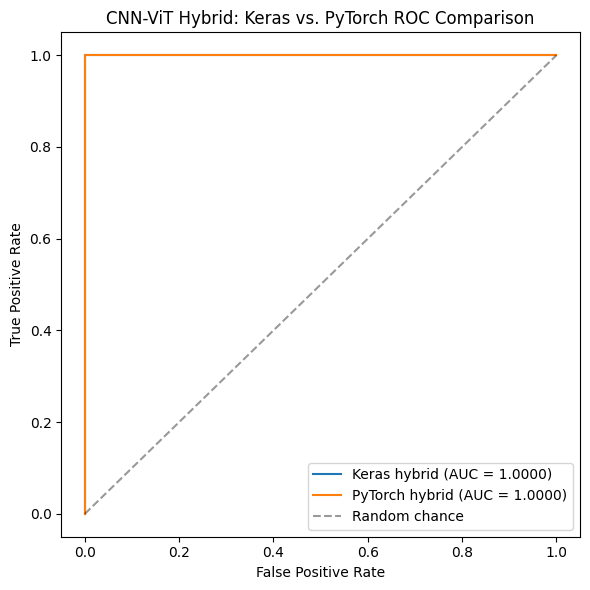

In [6]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_k, tpr_k, label=f"Keras hybrid (AUC = {auc_k:.4f})")
plt.plot(fpr_p, tpr_p, label=f"PyTorch hybrid (AUC = {auc_p:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN-ViT Hybrid: Keras vs. PyTorch ROC Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## Summary and discussion

This notebook showcased a framework-agnostic workflow for importing,
testing, and evaluating Vision Transformer (CNN-ViT hybrid) models built
in both Keras and PyTorch. By running the same input through each model,
we examined the compatibility of results and gained practical experience
handling architectural and data format variations.

Key insights:

* **Input format alignment matters** — PyTorch's channels-first
  `(N, C, H, W)` layout must be explicitly converted to Keras'
  channels-last `(N, H, W, C)` layout (or vice versa) before comparing
  predictions.
* **Model loading differs by framework** — Keras' `.keras` format is
  self-contained (architecture + weights), while PyTorch typically
  requires re-declaring the architecture in code before loading a
  `state_dict`.
* **Small framework-induced variations are expected** — differing default
  initializations, layer implementation details (e.g. `BatchNorm`
  momentum conventions, attention dropout placement), and floating-point
  operation ordering mean two "identical" architectures trained
  independently in each framework won't produce bit-identical
  predictions, even though their aggregate performance may be very close.

For a more robust evaluation, this process could be repeated with a
larger, independently labelled validation dataset, additional metrics
(e.g. per-class precision/recall breakdowns), and a systematic comparison
of inference speed and memory/resource usage across frameworks.
